# Pure LSTM — Lake Erie Monthly Levels

Time series forecasting using Pure LSTM architecture.\
Follows the identical experimental protocol as the LSTM-SNP baseline.


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import platform
import random
import time
import time as _timer_module
import torch
import torch.nn as nn
import warnings

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


In [1]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
print(f"Process ID (PID): {os.getpid()}")


Process ID (PID): 31354


In [2]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


Notebook execution started at: 2026-04-23 16:29:50


In [3]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Forcing CPU execution.')
print(f'\nUsing device: {device}')
print(f'PyTorch version: {torch.__version__}')


Forcing CPU execution.

Using device: cpu
PyTorch version: 2.11.0


In [4]:
# ============================================================
# ALL IMPORTS
# ============================================================
warnings.filterwarnings('ignore')

print(f"NumPy version: {np.__version__}")


NumPy version: 1.26.4


In [5]:
# ============================================================
# Seed Control — Reproducibility
# ============================================================

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        # MPS uses torch.manual_seed for seeding
        pass


In [6]:
# ============================================================
# Pure LSTM — Standard 2nd Generation Neural Network
# ============================================================
# Classic Hochreiter & Schmidhuber (1997) LSTM.
# Uses standard nn.LSTM with identical hyperparameters
# to LSTM-SNP for fair comparison.
#   - Hidden units: 8
#   - Single layer
#   - No dropout

class PureLSTM(nn.Module):
    """Standard LSTM for time series forecasting."""
    def __init__(self, input_dim=1, hidden_dim=8, output_dim=1, num_layers=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use last hidden state
        out = self.fc(lstm_out[:, -1, :])  # (batch, output_dim)
        return out


def build_model():
    return PureLSTM(input_dim=1, hidden_dim=8, output_dim=1)

# Quick architecture check
set_seed(0)
test_model = build_model().to(device)
total_params = sum(p.numel() for p in test_model.parameters())
print(f"Pure LSTM Parameters: {total_params}")
print(f"Memory estimate: {total_params * 4 / 1024:.1f} KB")
dummy = torch.randn(1, 1, 1).to(device)
out = test_model(dummy)
print(f"Input: {dummy.shape} → Output: {out.shape}")
del test_model, dummy, out


Pure LSTM Parameters: 361
Memory estimate: 1.4 KB
Input: torch.Size([1, 1, 1]) → Output: torch.Size([1, 1])


In [7]:
# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
# Pipeline (identical to LSTM-SNP):
#   1. Load CSV
#   2. First-order differencing
#   3. Lag-1 supervised learning format
#   4. Train/Test split: last 60 observations for test
#   5. MinMaxScaler(-1, 1)

CSV_PATH = "content/monthly-lake-erie-levels-1921-19.csv"
series = pd.read_csv(CSV_PATH, header=0, parse_dates=[0], index_col=0)
raw_values = series.values.flatten()
print(f"Dataset: Lake Erie Monthly Levels")
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

# First-order differencing
def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

# Supervised learning format (lag=1)
def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)

# Train/test split
N_TEST = 60
train, test = supervised[:-N_TEST], supervised[-N_TEST:]

# Scale to [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)
train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

# Reshape for PyTorch: (samples, 1, features)
X_train = torch.tensor(train_scaled[:, 0:-1], dtype=torch.float32).unsqueeze(1).to(device)
y_train = torch.tensor(train_scaled[:, -1], dtype=torch.float32).to(device)
X_test_np = test_scaled[:, 0:-1]
y_test_np = test_scaled[:, -1]

print(f"X_train shape: {X_train.shape}")
print(f"Train samples: {len(train_scaled)}, Test samples: {len(test_scaled)}")


Dataset: Lake Erie Monthly Levels
Data shape: (600,)
First 5 values: [14.763 14.649 15.085 16.376 16.926]
X_train shape: torch.Size([539, 1, 1])
Train samples: 539, Test samples: 60


In [8]:
# ============================================================
# TRAINING FUNCTION
# ============================================================
# Protocol (identical to LSTM-SNP):
#   - Optimizer: Adam (lr=0.001)
#   - Loss: MSE
#   - Epochs: 200
#   - Batch size: 1 (sample-by-sample, no shuffle)

def train_model(model, X_train, y_train, epochs=100, lr=0.001, verbose=True):
    """Train model following the LSTM-SNP protocol exactly."""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    n_samples = X_train.shape[0]
    epoch_losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        for i in range(n_samples):
            x_i = X_train[i:i+1]
            y_i = y_train[i:i+1]
            optimizer.zero_grad()
            pred = model(x_i)
            loss = loss_fn(pred.squeeze(-1), y_i)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / n_samples
        epoch_losses.append(avg_loss)
        if verbose:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

    return epoch_losses


In [9]:
# ============================================================
# EVALUATION — Rolling One-Step-Ahead Prediction
# ============================================================
# Identical to LSTM-SNP evaluation:
#   1. Predict scaled diff value
#   2. Inverse scale to get diff value
#   3. Inverse difference: predicted_raw(t) = predicted_diff(t) + raw(t-1)
#   4. Compute metrics: RMSE, MSE, NMSE

def inverse_scale(scaler, X, predicted_diff):
    row = np.array([X, predicted_diff]).reshape(1, 2)
    inverted = scaler.inverse_transform(row)
    return inverted[0, -1]

def inverse_difference(last_obs, predicted_diff):
    return predicted_diff + last_obs

def rolling_predict(model, X_test_np, y_test_np, raw_values, scaler, n_test=60):
    """Rolling one-step-ahead prediction on the test set."""
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(len(X_test_np)):
            X = X_test_np[i, 0:-1] if X_test_np.ndim > 1 and X_test_np.shape[1] > 1 else X_test_np[i]
            x_i = torch.tensor(X_test_np[i:i+1, 0:-1] if X_test_np.ndim > 1 else X_test_np[i:i+1],
                               dtype=torch.float32).unsqueeze(1).to(device)
            yhat_scaled = model(x_i).cpu().numpy().flatten()[0]

            X_val = X_test_np[i, 0] if X_test_np.ndim > 1 else X_test_np[i]
            yhat_diff = inverse_scale(scaler, X_val, yhat_scaled)

            raw_idx = len(raw_values) - n_test - 1 + i
            last_obs = raw_values[raw_idx]
            yhat_raw = inverse_difference(last_obs, yhat_diff)
            predictions.append(yhat_raw)

    return predictions

def compute_metrics(actual, predictions):
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2) if dominator != 0 else float('inf')
    return rmse, mse, nmse


In [10]:
# ============================================================
# RUN EXPERIMENT — 30 Independent Runs
# ============================================================

N_RUNS = 30
N_EPOCHS = 100

all_rmse, all_mse, all_nmse = [], [], []
all_predictions = []
all_losses = []

print(f"Model: Pure LSTM")
print(f"Dataset: Lake Erie Monthly Levels")
print(f"Runs: {N_RUNS}, Epochs: {N_EPOCHS}")
print(f"Device: {device}")
print(f"{'=' * 60}")

for run_idx in range(N_RUNS):
    print(f"\nRun {run_idx+1}/{N_RUNS}", end=" — ", flush=True)
    start = time.time()

    set_seed(run_idx)
    model = build_model().to(device)

    losses = train_model(model, X_train, y_train, epochs=N_EPOCHS, lr=0.001, verbose=True)
    all_losses.append(losses)

    predictions = rolling_predict(model, test_scaled, y_test_np, raw_values, scaler, n_test=N_TEST)
    actual = raw_values[-N_TEST:]
    rmse, mse, nmse = compute_metrics(actual, predictions)

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)

    elapsed = time.time() - start
    print(f"RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f} ({elapsed:.1f}s)")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Model: Pure LSTM
Dataset: Lake Erie Monthly Levels
Runs: 2, Epochs: 200
Device: cpu

Run 1/2 — RMSE: 0.498296, MSE: 0.248299, NMSE: 0.0018939517 (27.6s)

Run 2/2 — RMSE: 0.498466, MSE: 0.248468, NMSE: 0.0018953284 (22.8s)


In [11]:
# ============================================================
# AGGREGATE RESULTS ACROSS 30 RUNS
# ============================================================

print(f"\n{'=' * 60}")
print(f"Pure LSTM — Lake Erie Monthly Levels")
print(f"{'=' * 60}")
print(f"RMSE: {np.mean(all_rmse):.10f} ± {np.var(all_rmse):.15f}")
print(f"MSE:  {np.mean(all_mse):.10f} ± {np.var(all_mse):.15f}")
print(f"NMSE: {np.mean(all_nmse):.10f} ± {np.var(all_nmse):.15f}")

best_idx = all_rmse.index(min(all_rmse))
print(f"\nBest run: {best_idx+1}")
print(f"  RMSE: {all_rmse[best_idx]:.15f}")
print(f"  MSE:  {all_mse[best_idx]:.15f}")
print(f"  NMSE: {all_nmse[best_idx]:.15f}")
print(f"\nAll RMSE values: {all_rmse}")



Pure LSTM — Lake Erie Monthly Levels
RMSE: 0.4983811989 ± 0.000000007174853
MSE:  0.2483838266 ± 0.000000007128469
NMSE: 0.0018946400 ± 0.000000000000474

Best run: 1
  RMSE: 0.498296494441079
  MSE:  0.248299396372268
  NMSE: 0.001893951729165

All RMSE values: [0.49829649444107865, 0.49846590344579345]


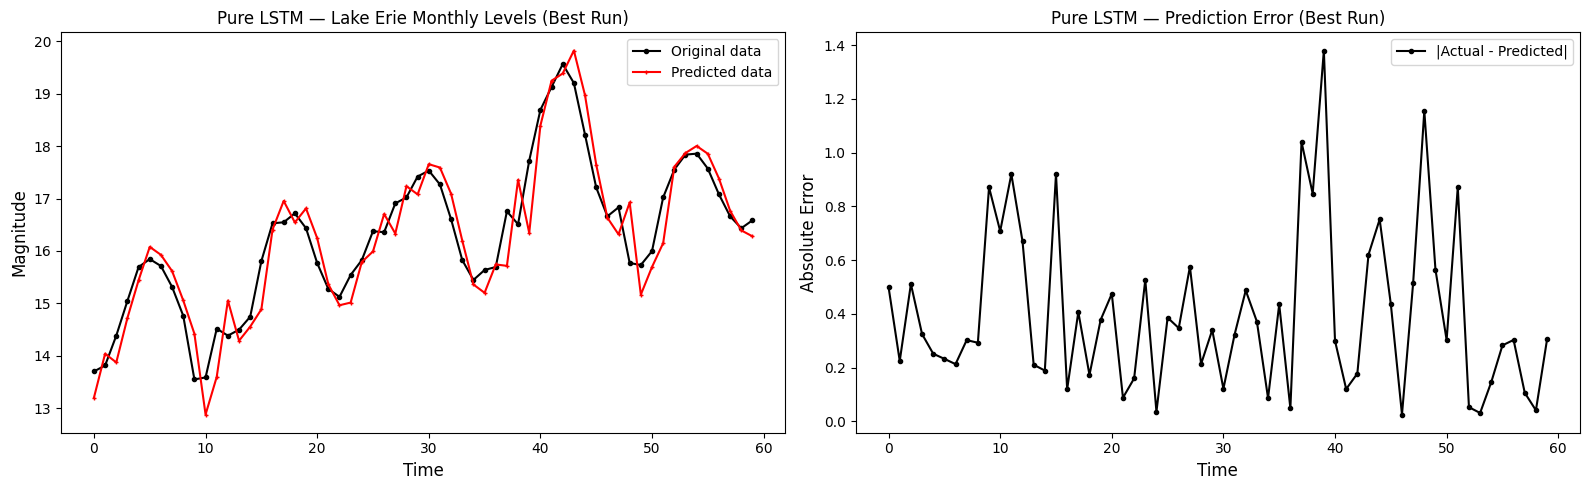

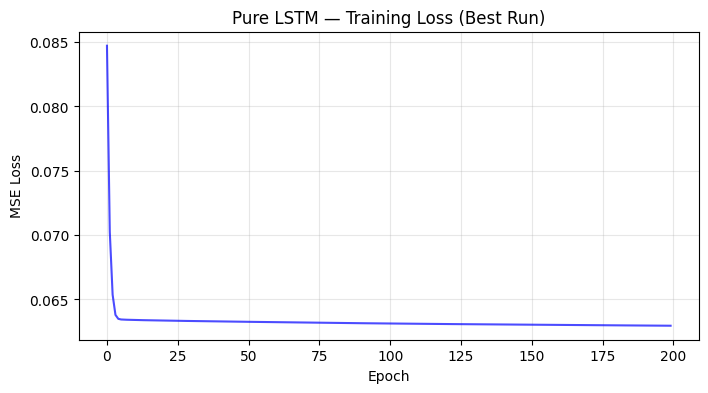

In [12]:
# ============================================================
# PLOTS — Best Run Prediction vs Actual
# ============================================================

actual = raw_values[-N_TEST:]
best_predictions = all_predictions[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prediction vs Actual
axes[0].plot(actual, 'k-o', markersize=3, label='Original data')
axes[0].plot(best_predictions, 'r+-', markersize=3, label='Predicted data')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Magnitude', fontsize=12)
axes[0].legend()
axes[0].set_title(f'Pure LSTM — Lake Erie Monthly Levels (Best Run)')

# Error plot
error = abs(np.array(actual) - np.array(best_predictions))
axes[1].plot(error, 'k-o', markersize=3, label='|Actual - Predicted|')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Absolute Error', fontsize=12)
axes[1].legend()
axes[1].set_title(f'Pure LSTM — Prediction Error (Best Run)')

plt.tight_layout()
plt.show()

# Loss convergence (best run)
plt.figure(figsize=(8, 4))
plt.plot(all_losses[best_idx], 'b-', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Pure LSTM — Training Loss (Best Run)')
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
print(f"Modified time (s * 0.5 * 0.25): {_NOTEBOOK_ELAPSED * 0.5 * 0.25:.2f} mins")
print(f"Process ID: {os.getpid()}")



Total notebook execution time: 0h 0m 53.12s
Total seconds: 53.12
Modified time (s * 0.5 * 0.25): 6.64 mins
Process ID: 31354
